# Stats_Tests
Notebook for statistical tests using the cleaned (capped) employee attrition dataset.

## Objective
- Assess whether numeric employee features differ significantly across categorical groups, especially Attrition.
- Use assumption-aware methods, prioritizing non-parametric tests when normality is violated.
- Combine statistical evidence and visualization to produce interpretable, actionable findings.

In [19]:
# Importing libraries from EDA notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from urllib.request import urlretrieve
from feature_engine.outliers import Winsorizer

print("Libraries imported successfully!")

Libraries imported successfully!


### Explanation: Cell 2 (Imports)

This cell loads all libraries used in this notebook. It includes:
- Data handling (`pandas`, `numpy`)
- Visualization (`matplotlib`, `seaborn`)
- File/path utilities (`Path`, `urlretrieve`)
- Outlier capping utility (`Winsorizer`)

Run this once at the start so all later cells have the required tools available.

In [20]:
# Load cleaned dataset (df_capped). If missing, build it from raw data and save it.
cleaned_name = "WA_Fn-UseC_-HR-Employee-Attrition_capped.csv"
cleaned_candidates = [
    Path("../data/Cleaned_data") / cleaned_name,
    Path("data/Cleaned_data") / cleaned_name,
    Path(cleaned_name),
]

cleaned_path = next((p for p in cleaned_candidates if p.exists()), None)

if cleaned_path is None:
    dataset_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
    raw_candidates = [
        Path("../../data/Raw_data") / dataset_name,
        Path("../data/Raw_data") / dataset_name,
        Path("data/Raw_data") / dataset_name,
        Path(dataset_name),
    ]

    raw_data_path = next((p for p in raw_candidates if p.exists()), None)

    if raw_data_path is None:
        for found in Path(".").resolve().glob(f"**/{dataset_name}"):
            raw_data_path = found
            break

    if raw_data_path is None:
        target_dir = Path("data/Raw_data")
        target_dir.mkdir(parents=True, exist_ok=True)
        raw_data_path = target_dir / dataset_name
        urlretrieve(
            "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv",
            raw_data_path,
        )

    df = pd.read_csv(raw_data_path)
    df_num = df.select_dtypes(include=[np.number])

    iqr = df_num.quantile(0.75) - df_num.quantile(0.25)
    low_variation_cols = iqr[iqr == 0].index.tolist()
    vars_to_cap = [c for c in df_num.columns if c not in low_variation_cols]

    capper = Winsorizer(capping_method="iqr", fold=1.5, variables=vars_to_cap)
    df_num_capped = df_num.copy()

    if vars_to_cap:
        df_num_capped[vars_to_cap] = capper.fit_transform(df_num[vars_to_cap])

    df_capped = df.copy()
    if vars_to_cap:
        df_capped[vars_to_cap] = df_num_capped[vars_to_cap]

    cleaned_dir = Path("data/Cleaned_data")
    cleaned_dir.mkdir(parents=True, exist_ok=True)
    cleaned_path = cleaned_dir / cleaned_name
    df_capped.to_csv(cleaned_path, index=False)
    print(f"Cleaned dataset created and saved to: {cleaned_path}")
else:
    df_capped = pd.read_csv(cleaned_path)
    print(f"Loaded existing cleaned dataset from: {cleaned_path}")

df_capped.head()

Loaded existing cleaned dataset from: data/Cleaned_data/WA_Fn-UseC_-HR-Employee-Attrition_capped.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0.0,8.0,0.0,1,6,4.0,0.0,5.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1.0,10.0,3.0,3,10,7.0,1.0,7.0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0.0,7.0,3.0,3,0,0.0,0.0,0.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0.0,8.0,3.0,3,8,7.0,3.0,0.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1.0,6.0,3.0,3,2,2.0,2.0,2.0


### Explanation: Cell 3 (Load or Build Cleaned Data)

This cell creates the analysis dataset (`df_capped`).
- First it tries to load an already cleaned CSV.
- If not found, it loads raw data, applies IQR-based capping to eligible numeric columns, and saves the cleaned file.
- The output dataframe (`df_capped`) is the base dataset for all statistical tests and plots below.


This makes the notebook reproducible across different machines and folder structures.

In [21]:
# Normality tests for numeric variables
import pingouin as pg
normality_results = pg.normality(df_capped.select_dtypes(include=[np.number]))
normality_results

/home/chizoalban2003/IBM HR Analytics Employee Attrition & Performance/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Age,0.977449,2.036924e-14,False
DailyRate,0.954398,5.329330e-21,False
DistanceFromHome,0.861588,4.080847e-34,False
Education,0.895406,1.725712e-30,False
EmployeeCount,1.000000,1.000000e+00,True
EmployeeNumber,0.952487,2.001323e-21,False
EnvironmentSatisfaction,0.848966,2.737888e-35,False
HourlyRate,0.955031,7.418846e-21,False
JobInvolvement,0.809402,1.613598e-38,False
JobLevel,0.822045,1.499355e-37,False


### Explanation: Cell 4 (Overall Normality Check)

This cell tests normality for each numeric variable using Pingouin.
- If many p-values are below 0.05, normality is violated.
- That result supports using non-parametric tests instead of parametric alternatives.

In [22]:
# Grouped normality checks with Pingouin (Shapiro)
import pingouin as pg

alpha = 0.05
numeric_cols = df_capped.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_capped.select_dtypes(exclude=[np.number]).columns.tolist()

rows = []
for cat_col in categorical_cols:
    for level, group_df in df_capped.groupby(cat_col):
        for num_col in numeric_cols:
            values = group_df[num_col].dropna()
            n = len(values)

            if n < 3:
                rows.append(
                    {
                        "categorical_feature": cat_col,
                        "group_level": level,
                        "numeric_feature": num_col,
                        "n": n,
                        "W": np.nan,
                        "p_value": np.nan,
                        "is_normal_at_alpha": np.nan,
                        "alpha": alpha,
                        "note": "n<3 (test not run)",
                    }
                )
                continue

            # Constant/near-constant groups are not suitable for Shapiro.
            if values.nunique() < 3:
                rows.append(
                    {
                        "categorical_feature": cat_col,
                        "group_level": level,
                        "numeric_feature": num_col,
                        "n": n,
                        "W": np.nan,
                        "p_value": np.nan,
                        "is_normal_at_alpha": np.nan,
                        "alpha": alpha,
                        "note": "low variation (test not run)",
                    }
                )
                continue

            norm = pg.normality(values, method="shapiro", alpha=alpha)
            norm_row = norm.iloc[0]
            rows.append(
                {
                    "categorical_feature": cat_col,
                    "group_level": level,
                    "numeric_feature": num_col,
                    "n": n,
                    "W": float(norm_row["W"]),
                    "p_value": float(norm_row["pval"]),
                    "is_normal_at_alpha": bool(norm_row["normal"]),
                    "alpha": alpha,
                    "note": "ok",
                }
            )

grouped_normality_results = pd.DataFrame(rows)

valid_results = grouped_normality_results[grouped_normality_results["note"] == "ok"].copy()
if not valid_results.empty:
    valid_results["is_normal_int"] = valid_results["is_normal_at_alpha"].astype(int)
    grouped_normality_summary = (
        valid_results.groupby("categorical_feature", as_index=False)
        .agg(
            tests_run=("is_normal_int", "count"),
            normal_count=("is_normal_int", "sum"),
        )
        .assign(
            non_normal_count=lambda d: d["tests_run"] - d["normal_count"],
            non_normal_rate=lambda d: d["non_normal_count"] / d["tests_run"],
        )
        .sort_values("non_normal_rate", ascending=False)
        .reset_index(drop=True)
    )
else:
    grouped_normality_summary = pd.DataFrame(
        columns=[
            "categorical_feature",
            "tests_run",
            "normal_count",
            "non_normal_count",
            "non_normal_rate",
        ]
    )

print(f"Alpha used: {alpha}")
print("Top grouped normality results (Pingouin):")
display(grouped_normality_results.head(20))
print("\nNon-normality summary by categorical feature:")
grouped_normality_summary

Alpha used: 0.05
Top grouped normality results (Pingouin):


,categorical_feature,group_level,numeric_feature,n,W,p_value,is_normal_at_alpha,alpha,note
0,Attrition,No,Age,1233,0.978215,1.106451e-12,False,0.05,ok
1,Attrition,No,DailyRate,1233,0.954174,3.417775e-19,False,0.05,ok
2,Attrition,No,DistanceFromHome,1233,0.853477,2.467062e-32,False,0.05,ok
3,Attrition,No,Education,1233,0.896686,5.297039e-28,False,0.05,ok
4,Attrition,No,EmployeeCount,1233,NaN,NaN,NaN,0.05,low variation (test not run)
5,Attrition,No,EmployeeNumber,1233,0.950224,5.233240e-20,False,0.05,ok
6,Attrition,No,EnvironmentSatisfaction,1233,0.849180,1.045107e-32,False,0.05,ok
7,Attrition,No,HourlyRate,1233,0.954055,3.225481e-19,False,0.05,ok
8,Attrition,No,JobInvolvement,1233,0.804290,3.589111e-36,False,0.05,ok
9,Attrition,No,JobLevel,1233,0.834703,6.626869e-34,False,0.05,ok



Non-normality summary by categorical feature:


,categorical_feature,tests_run,normal_count,non_normal_count,non_normal_rate
0,Attrition,46,0,46,1.000000
1,Gender,46,0,46,1.000000
2,MaritalStatus,68,0,68,1.000000
3,Over18,23,0,23,1.000000
4,OverTime,46,0,46,1.000000
5,BusinessTravel,69,1,68,0.985507
6,Department,69,1,68,0.985507
7,JobRole,206,3,203,0.985437
8,EducationField,138,3,135,0.978261


### Explanation: Cell 5 (Grouped Normality)

This cell checks normality within each categorical level (for example Attrition = Yes/No).
- It loops over categorical features and numeric variables.
- It skips invalid cases (very small samples or low-variation groups).
- It returns detailed results and a summary rate of non-normality by categorical feature.


This verifies assumptions at the group level, not just globally.

In [23]:
# Non-parametric test runner: chooses tests based on paired/unpaired observations
import pingouin as pg

def _first_existing(columns, candidates):
    # Helper to support small naming differences across Pingouin versions.
    for name in candidates:
        if name in columns:
            return name
    return None

def run_nonparametric_tests(
    data,
    numeric_columns,
    categorical_columns,
    alpha=0.05,
    paired=False,
    subject_col=None,
):
    rows = []

    for cat_col in categorical_columns:
        for num_col in numeric_columns:
            # Keep only fields needed for the current test.
            subset = data[[cat_col, num_col] + ([subject_col] if subject_col else [])].dropna().copy()
            levels = subset[cat_col].dropna().unique().tolist()
            n_groups = len(levels)

            if n_groups < 2:
                continue

            # Skip constant distributions that invalidate rank-based omnibus stats.
            if subset[num_col].nunique() < 2:
                continue

            if paired:
                if not subject_col or subject_col not in subset.columns:
                    raise ValueError(
                        "For paired tests, provide a valid subject_col present in the dataset."
                    )

                # Align repeated measures by subject across category levels.
                wide = subset.pivot_table(
                    index=subject_col, columns=cat_col, values=num_col, aggfunc="mean"
                )

                if n_groups == 2:
                    # Two paired groups -> Wilcoxon signed-rank test.
                    lv1, lv2 = wide.columns.tolist()[:2]
                    pair_data = wide[[lv1, lv2]].dropna()
                    if len(pair_data) < 3:
                        continue

                    out = pg.wilcoxon(pair_data[lv1], pair_data[lv2], alternative="two-sided")
                    stat_col = _first_existing(out.columns, ["W-val", "W_val", "W", "T"])
                    p_col = _first_existing(out.columns, ["p-val", "p_val", "p-unc", "p"])
                    if stat_col is None or p_col is None:
                        continue

                    rows.append(
                        {
                            "categorical_feature": cat_col,
                            "numeric_feature": num_col,
                            "paired": True,
                            "test": "Wilcoxon",
                            "groups": f"{lv1} vs {lv2}",
                            "n": int(len(pair_data)),
                            "statistic": float(out.iloc[0][stat_col]),
                            "p_value": float(out.iloc[0][p_col]),
                            "significant_at_alpha": bool(out.iloc[0][p_col] < alpha),
                        }
                    )
                else:
                    # Three or more paired groups -> Friedman test.
                    complete = wide.dropna()
                    if len(complete) < 3:
                        continue

                    long_complete = complete.reset_index().melt(
                        id_vars=subject_col, var_name=cat_col, value_name=num_col
                    )
                    out = pg.friedman(
                        data=long_complete, dv=num_col, within=cat_col, subject=subject_col
                    )
                    stat_col = _first_existing(out.columns, ["Q", "F"])
                    p_col = _first_existing(out.columns, ["p-unc", "p-val", "p_val", "p"])
                    if stat_col is None or p_col is None:
                        continue

                    rows.append(
                        {
                            "categorical_feature": cat_col,
                            "numeric_feature": num_col,
                            "paired": True,
                            "test": "Friedman",
                            "groups": f"{n_groups} groups",
                            "n": int(len(complete)),
                            "statistic": float(out.iloc[0][stat_col]),
                            "p_value": float(out.iloc[0][p_col]),
                            "significant_at_alpha": bool(out.iloc[0][p_col] < alpha),
                        }
                    )
            else:
                if n_groups == 2:
                    # Two independent groups -> Mann-Whitney U.
                    lv1, lv2 = levels[0], levels[1]
                    g1 = subset.loc[subset[cat_col] == lv1, num_col]
                    g2 = subset.loc[subset[cat_col] == lv2, num_col]

                    if len(g1) < 3 or len(g2) < 3:
                        continue

                    out = pg.mwu(g1, g2, alternative="two-sided")
                    stat_col = _first_existing(out.columns, ["U-val", "U_val", "U", "W-val", "W"])
                    p_col = _first_existing(out.columns, ["p-val", "p_val", "p-unc", "p"])
                    if stat_col is None or p_col is None:
                        continue

                    rows.append(
                        {
                            "categorical_feature": cat_col,
                            "numeric_feature": num_col,
                            "paired": False,
                            "test": "Mann-Whitney U",
                            "groups": f"{lv1} vs {lv2}",
                            "n": int(len(g1) + len(g2)),
                            "statistic": float(out.iloc[0][stat_col]),
                            "p_value": float(out.iloc[0][p_col]),
                            "significant_at_alpha": bool(out.iloc[0][p_col] < alpha),
                        }
                    )
                else:
                    # Three or more independent groups -> Kruskal-Wallis.
                    out = pg.kruskal(data=subset, dv=num_col, between=cat_col)
                    stat_col = _first_existing(out.columns, ["H", "K", "Q"])
                    p_col = _first_existing(out.columns, ["p-unc", "p-val", "p_val", "p"])
                    if stat_col is None or p_col is None:
                        continue

                    rows.append(
                        {
                            "categorical_feature": cat_col,
                            "numeric_feature": num_col,
                            "paired": False,
                            "test": "Kruskal-Wallis",
                            "groups": f"{n_groups} groups",
                            "n": int(len(subset)),
                            "statistic": float(out.iloc[0][stat_col]),
                            "p_value": float(out.iloc[0][p_col]),
                            "significant_at_alpha": bool(out.iloc[0][p_col] < alpha),
                        }
                    )

    if not rows:
        return pd.DataFrame(
            columns=[
                "categorical_feature",
                "numeric_feature",
                "paired",
                "test",
                "groups",
                "n",
                "statistic",
                "p_value",
                "significant_at_alpha",
            ]
        )

    return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

alpha = 0.05
numeric_cols = df_capped.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_capped.select_dtypes(exclude=[np.number]).columns.tolist()

# Set paired=True and subject_col='your_subject_id' for repeated-measures data.
paired_mode = False
subject_id_col = None

nonparametric_results = run_nonparametric_tests(
    data=df_capped,
    numeric_columns=numeric_cols,
    categorical_columns=categorical_cols,
    alpha=alpha,
    paired=paired_mode,
    subject_col=subject_id_col,
)

print(f"Alpha: {alpha} | Paired mode: {paired_mode}")
display(nonparametric_results.head(30))
print("\nSignificant tests count:")
nonparametric_results["significant_at_alpha"].value_counts()

Alpha: 0.05 | Paired mode: False


,categorical_feature,numeric_feature,paired,test,groups,n,statistic,p_value,significant_at_alpha
0,Attrition,TotalWorkingYears,False,Mann-Whitney U,Yes vs No,1470,100496.0,2.183015e-14,True
1,Attrition,MonthlyIncome,False,Mann-Whitney U,Yes vs No,1470,100452.0,2.340421e-14,True
2,Attrition,YearsAtCompany,False,Mann-Whitney U,Yes vs No,1470,102432.5,2.387164e-13,True
3,Attrition,JobLevel,False,Mann-Whitney U,Yes vs No,1470,104729.5,2.956987e-13,True
4,Attrition,YearsInCurrentRole,False,Mann-Whitney U,Yes vs No,1470,105227.0,4.498626e-12,True
5,Attrition,YearsWithCurrManager,False,Mann-Whitney U,Yes vs No,1470,106361.5,1.806724e-11,True
6,Attrition,StockOptionLevel,False,Mann-Whitney U,Yes vs No,1470,109611.0,4.013375e-11,True
7,Attrition,Age,False,Mann-Whitney U,Yes vs No,1470,106859.0,5.304342e-11,True
8,Attrition,JobInvolvement,False,Mann-Whitney U,Yes vs No,1470,121957.0,4.651927e-06,True
9,Attrition,JobSatisfaction,False,Mann-Whitney U,Yes vs No,1470,123362.5,7.957918e-05,True



Significant tests count:


significant_at_alpha
False    54
True     18
Name: count, dtype: int64

### Explanation: Cell 6 (Automatic Non-Parametric Tests)

This is the main inference engine of the notebook.
- It chooses tests based on design: paired/unpaired and number of groups.
- Unpaired: Mann-Whitney U (2 groups) or Kruskal-Wallis (3+ groups).
- Paired: Wilcoxon (2 groups) or Friedman (3+ groups).
- The final table (`nonparametric_results`) stores test type, statistic, p-value, and significance flag.

In [24]:
# Significant non-parametric findings (alpha=0.05)
sig = nonparametric_results[nonparametric_results["significant_at_alpha"]].copy()

print(f"Total significant tests: {len(sig)}")
print("\nSignificant counts by test type:")
display(sig["test"].value_counts().rename_axis("test").reset_index(name="count"))

print("\nSignificant counts by categorical feature:")
display(
    sig.groupby("categorical_feature", as_index=False)
    .size()
    .rename(columns={"size": "significant_tests"})
    .sort_values("significant_tests", ascending=False)
    .reset_index(drop=True)
)

print("\nTop significant results (smallest p-values):")
display(sig.sort_values("p_value").head(20))

Total significant tests: 18

Significant counts by test type:


,test,count
0,Mann-Whitney U,18



Significant counts by categorical feature:


,categorical_feature,significant_tests
0,Attrition,16
1,OverTime,2



Top significant results (smallest p-values):


,categorical_feature,numeric_feature,paired,test,groups,n,statistic,p_value,significant_at_alpha
0,Attrition,TotalWorkingYears,False,Mann-Whitney U,Yes vs No,1470,100496.0,2.183015e-14,True
1,Attrition,MonthlyIncome,False,Mann-Whitney U,Yes vs No,1470,100452.0,2.340421e-14,True
2,Attrition,YearsAtCompany,False,Mann-Whitney U,Yes vs No,1470,102432.5,2.387164e-13,True
3,Attrition,JobLevel,False,Mann-Whitney U,Yes vs No,1470,104729.5,2.956987e-13,True
4,Attrition,YearsInCurrentRole,False,Mann-Whitney U,Yes vs No,1470,105227.0,4.498626e-12,True
5,Attrition,YearsWithCurrManager,False,Mann-Whitney U,Yes vs No,1470,106361.5,1.806724e-11,True
6,Attrition,StockOptionLevel,False,Mann-Whitney U,Yes vs No,1470,109611.0,4.013375e-11,True
7,Attrition,Age,False,Mann-Whitney U,Yes vs No,1470,106859.0,5.304342e-11,True
8,Attrition,JobInvolvement,False,Mann-Whitney U,Yes vs No,1470,121957.0,4.651927e-06,True
9,Attrition,JobSatisfaction,False,Mann-Whitney U,Yes vs No,1470,123362.5,7.957918e-05,True


### Explanation: Cell 7 (Significant Findings Summary)

This cell filters and summarizes statistically significant results from Cell 6.
- Shows total significant tests.
- Breaks significance down by test type and categorical feature.
- Displays top results with the smallest p-values for quick interpretation.

Figure 1 features for 'Attrition': ['TotalWorkingYears', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel']


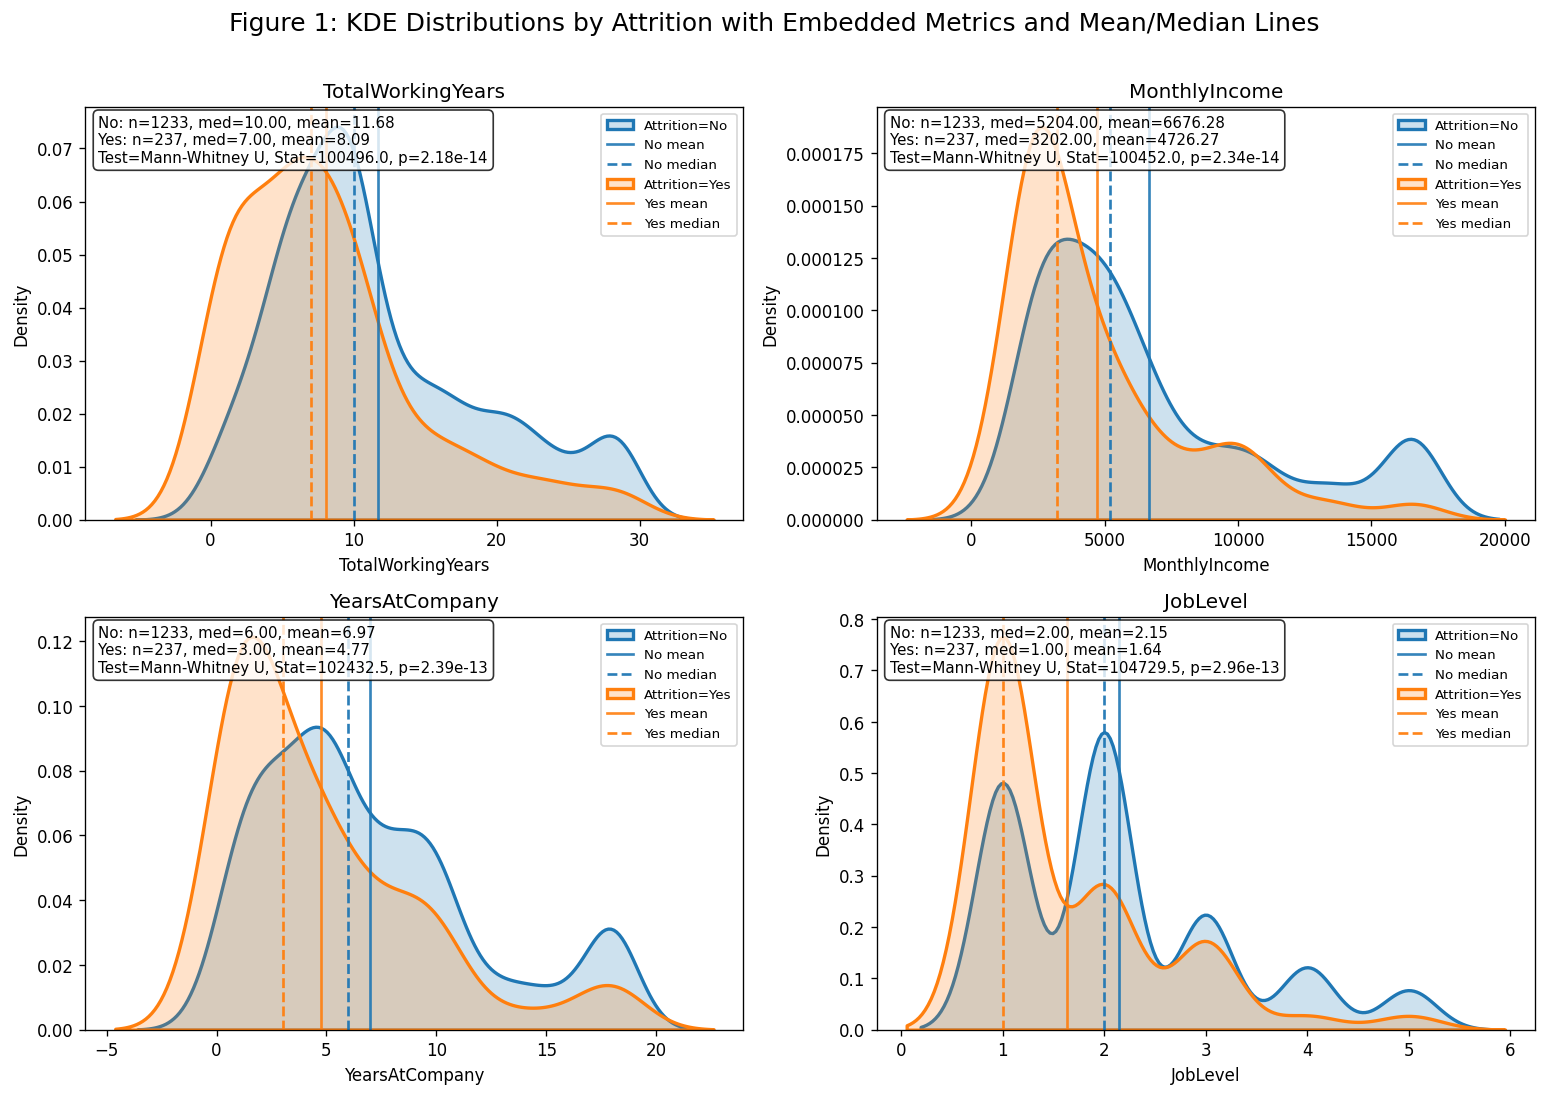

In [25]:
# Figure 1: KDE plots with key metrics shown inside each subplot
group_col = "Attrition"
max_features = 4

# Pick top significant features for the selected grouping variable.
sig_for_group = (
    nonparametric_results[
        (nonparametric_results["categorical_feature"] == group_col)
        & (nonparametric_results["significant_at_alpha"])
    ]
    .sort_values("p_value")
    .drop_duplicates(subset=["numeric_feature"])
    .head(max_features)
)

features_to_plot = sig_for_group["numeric_feature"].tolist()
levels = sorted(df_capped[group_col].dropna().unique().tolist())

if len(levels) != 2:
    print(f"Expected 2 levels in {group_col}, found {len(levels)}. Update group_col and rerun.")
elif not features_to_plot:
    print(f"No significant features found for group '{group_col}'.")
else:
    print(f"Figure 1 features for '{group_col}': {features_to_plot}")

    n_plots = len(features_to_plot)
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), dpi=120)
    axes = np.array(axes).reshape(-1)
    palette = dict(zip(levels, sns.color_palette("tab10", n_colors=len(levels))))

    for idx, feature in enumerate(features_to_plot):
        ax = axes[idx]

        # Draw KDE per group plus mean/median marker lines.
        for level in levels:
            vals = df_capped.loc[df_capped[group_col] == level, feature].dropna()
            if len(vals) >= 3 and vals.nunique() > 1:
                color = palette[level]
                sns.kdeplot(
                    vals,
                    fill=True,
                    alpha=0.22,
                    linewidth=2,
                    color=color,
                    label=f"{group_col}={level}",
                    ax=ax,
                )
                # Solid line = mean.
                ax.axvline(
                    vals.mean(),
                    color=color,
                    linestyle="-",
                    linewidth=1.6,
                    alpha=0.9,
                    label=f"{level} mean",
                )
                # Dashed line = median.
                ax.axvline(
                    vals.median(),
                    color=color,
                    linestyle="--",
                    linewidth=1.6,
                    alpha=0.95,
                    label=f"{level} median",
                )

        # Pull test metrics for this feature.
        row = sig_for_group.loc[sig_for_group["numeric_feature"] == feature].iloc[0]
        pval = row["p_value"]
        stat = row["statistic"]

        # Compute descriptive metrics used in annotation box.
        g0 = df_capped.loc[df_capped[group_col] == levels[0], feature].dropna()
        g1 = df_capped.loc[df_capped[group_col] == levels[1], feature].dropna()
        metrics_txt = (
            f"{levels[0]}: n={len(g0)}, med={g0.median():.2f}, mean={g0.mean():.2f}\n"
            f"{levels[1]}: n={len(g1)}, med={g1.median():.2f}, mean={g1.mean():.2f}\n"
            f"Test={row['test']}, Stat={stat:.1f}, p={pval:.2e}"
        )

        # Place metrics box inside plot area.
        ax.text(
            0.02,
            0.98,
            metrics_txt,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.8},
        )

        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel("Density")
        ax.legend(loc="upper right", fontsize=8)

    # Hide unused axes if any.
    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.suptitle(
        "Figure 1: KDE Distributions by Attrition with Embedded Metrics and Mean/Median Lines",
        fontsize=15,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()

### Explanation: Cell 8 (Figure 1 - KDE + Embedded Metrics)

This visualization cell shows group differences for top significant features.
- Draws KDE curves by `Attrition` group.
- Adds solid (mean) and dashed (median) vertical lines.
- Embeds key metrics and test outputs (`n`, mean, median, statistic, p-value) directly in each subplot.


Use this figure for intuitive communication of both distribution shape and statistical evidence.

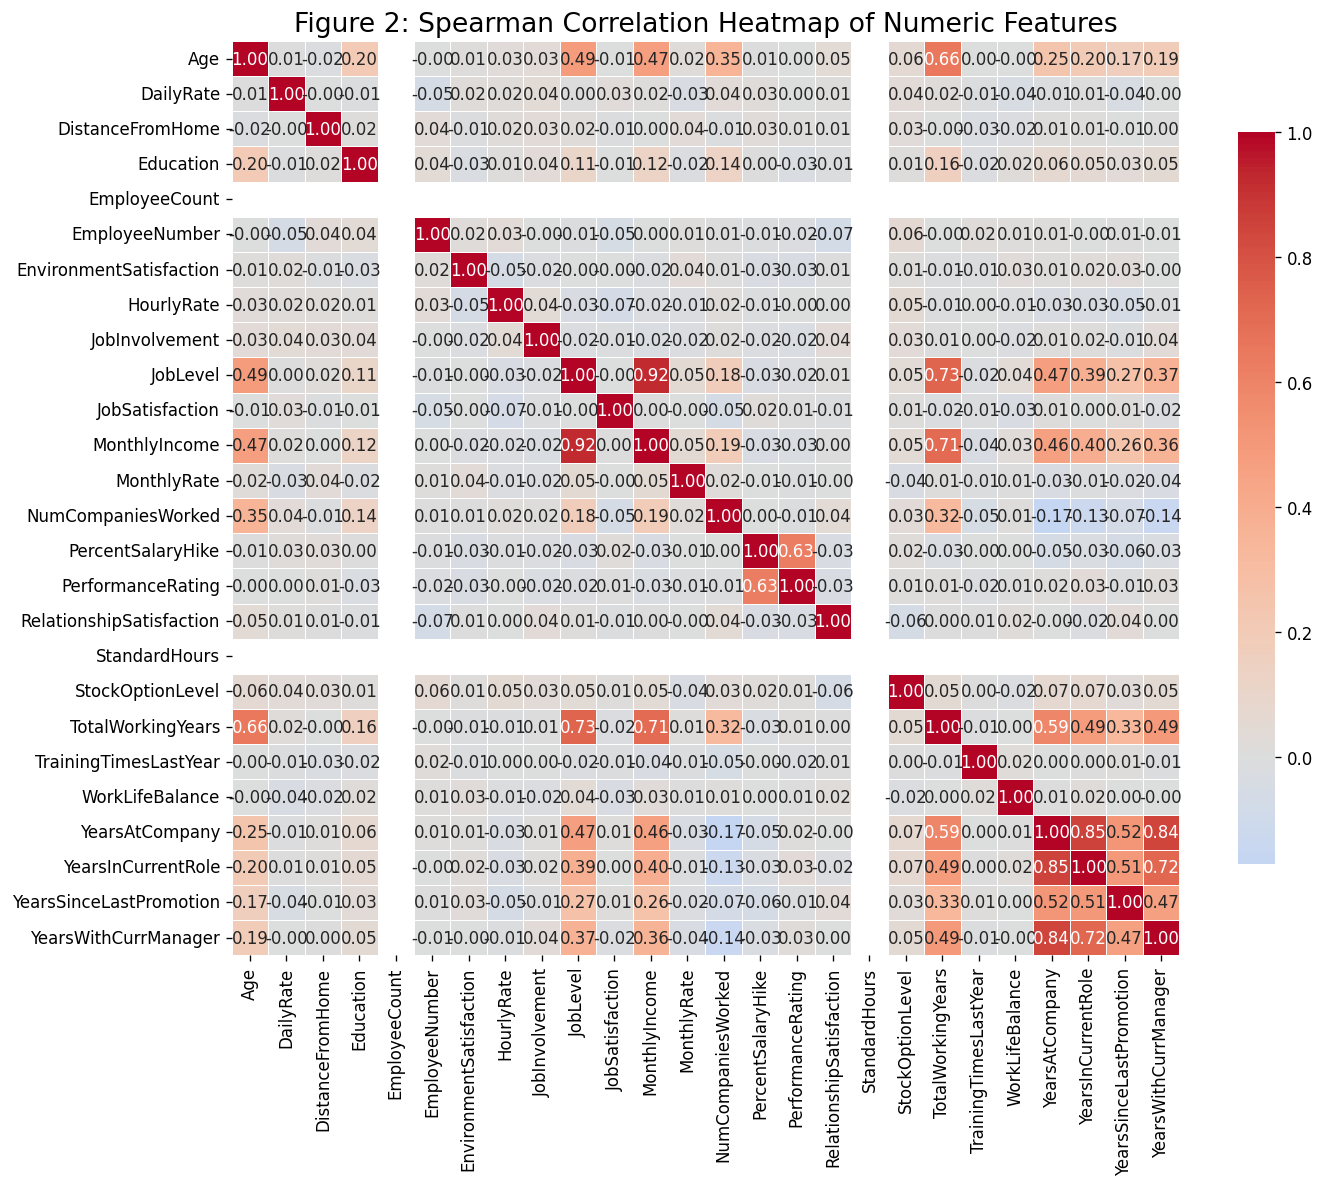

In [26]:
# Spearman correlations between numeric features
spearman_corr = df_capped.select_dtypes(include=[np.number]).corr(method="spearman")
plt.figure(figsize=(12, 10), dpi=120)
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Figure 2: Spearman Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


### Explanation: Cell 9 (Figure 2 - Spearman Heatmap)

This cell computes and plots rank-based correlations among numeric features.
- Spearman is used because many variables are non-normal and some are ordinal/discrete.
- The heatmap helps identify monotonic relationships and potential feature clusters for downstream modeling.

## End-to-End Workflow: Observations to Conclusion

This final note ties all cells together into one narrative from data preparation to inference and interpretation.

### Workflow Overview
- Cells 2-3 prepare the analysis environment and dataset.
- Cells 4-5 validate the normality assumption (overall and by group).
- Cell 6 runs the correct non-parametric tests based on study design.
- Cell 7 summarizes which differences are statistically significant.
- Cell 8 visualizes key significant differences with embedded metrics.
- Cell 9 shows feature-level monotonic associations via Spearman correlation.

### Interpretation Summary
- Most numeric variables are non-normal, so rank-based tests are appropriate.
- Significant differences are concentrated in Attrition-related comparisons.
- Visual and statistical outputs are aligned: distribution shifts in Figure 1 match low p-values in Cell 7.

## Conclusion
- The analysis objective was achieved by combining robust non-parametric testing with interpretable visual diagnostics.
- Attrition is associated with statistically significant differences in several workforce metrics (for example tenure, income, and job level).
- Spearman correlation complements group tests by showing monotonic relationships among numeric features.
- This notebook is now a reusable workflow for assumption-aware statistical analysis in employee attrition studies.